# Purpose:
- There were cells without any detected inferred events, which breaks GLM
- It will also impact downstream analyses.
- Keeping record of them.
- Examples: 'VISp_3_0053', 'VISp_1_0021', 'VISp_5_0100', 'VISp_0_0005', 'VISp_0_0060', 'VISp_4_0038', 'VISp_2_0007', 'VISp_2_0048'
   - From 736963_2024-07-24

In [7]:
import numpy as np
%matplotlib inline

In [3]:
from matplotlib import pyplot as plt
from comb.behavior_ophys_dataset import BehaviorOphysDataset

bod = BehaviorOphysDataset(raw_folder_path='/root/capsule/data/multiplane-ophys_736963_2024-07-24_08-49-57',
                           plane_folder_path='/root/capsule/data/multiplane-ophys_736963_2024-07-24_08-49-57_processed_2024-11-20_20-41-20/VISp_0',
                           pipeline_version='v6')

- Proportion of event frames can be one criteria to remove cells
- Set this as 0.01 (Less than 1% of frames have detected events)


Text(0.5, 1.0, '736963_2024-07-24_VISp_0')

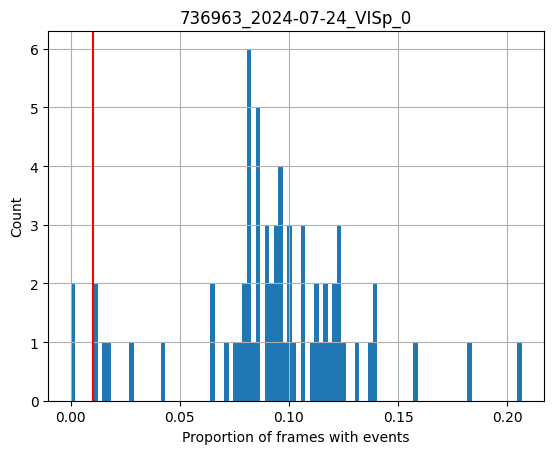

In [9]:
events_table = bod.events[['events']].copy()
events_table['prop_support'] = events_table.events.apply(lambda x: len(np.where(x)[0])/len(x))

fig, ax = plt.subplots()
events_table.prop_support.hist(bins=100, ax=ax)
ax.axvline(0.01, color='r')
ax.set_xlabel('Proportion of frames with events')
ax.set_ylabel('Count')
ax.set_title(bod.metadata['plane']['plane_session_key'])

### How do they look?
- One ROI looks like a cell
- Another looks like it should have been filtered out (ROI classifier in dev)

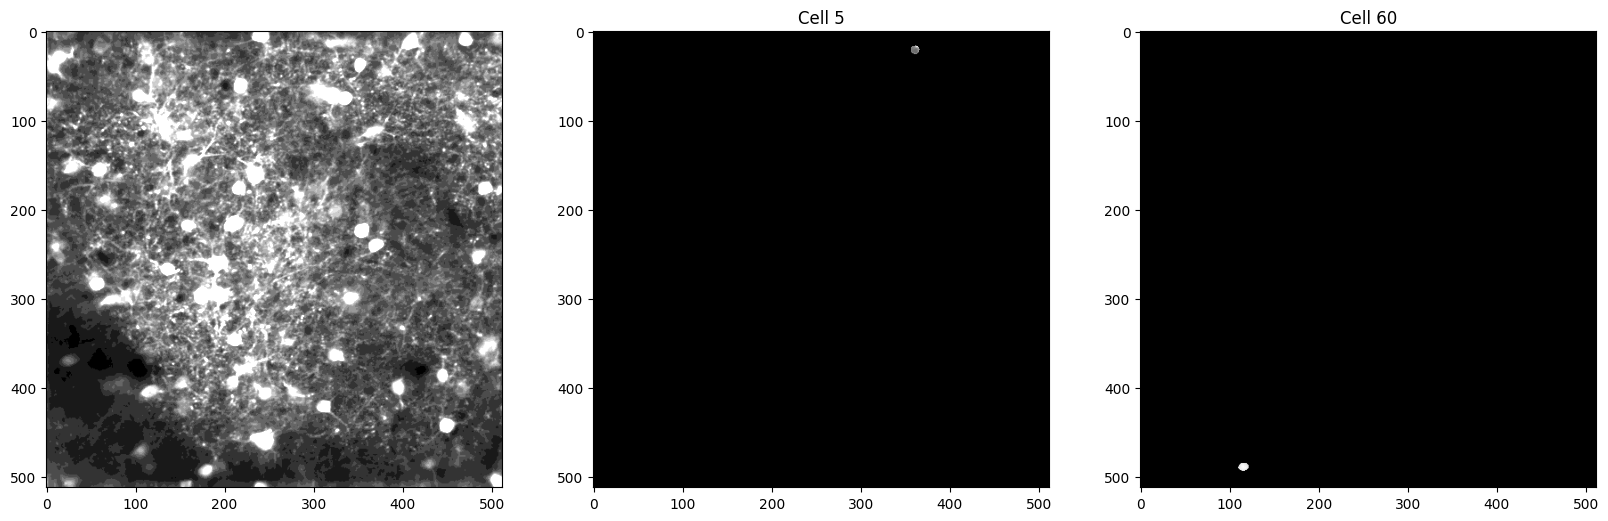

In [15]:
cids = [5, 60]
fig, ax = plt.subplots(1, 3, figsize=(20, 7))
ax[0].imshow(bod.average_projection, cmap='gray', vmax=np.percentile(bod.average_projection, 95))
for i, cid in enumerate(cids):
    cell_row = bod.cell_specimen_table.query('cell_roi_id==@cid')
    ax[i+1].imshow(cell_row.mask_matrix.values[0], cmap='gray')
    ax[i+1].set_title(f'Cell {cid}')


### Checking their traces

Text(0.5, 0.98, 'Cell 5')

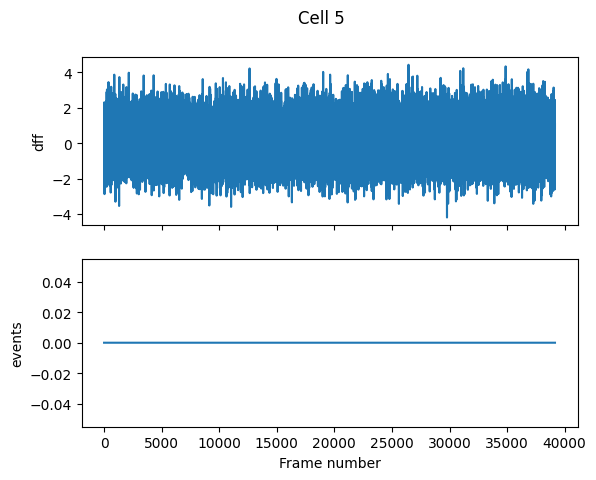

In [16]:
fig, ax = plt.subplots(2, 1, sharex=True)
cid = 5
ax[0].plot(bod.dff_traces.loc[cid].dff)
ax[0].set_ylabel('dff')
ax[1].plot(bod.events.loc[cid].events)
ax[1].set_ylabel('events')
ax[1].set_xlabel('Frame number')
fig.suptitle(f'Cell {cid}')

Text(0.5, 0.98, 'Cell 60')

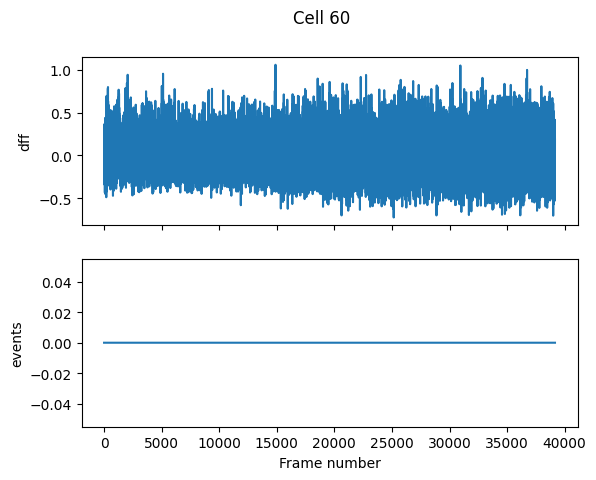

In [17]:
fig, ax = plt.subplots(2, 1, sharex=True)
cid = 60
ax[0].plot(bod.dff_traces.loc[cid].dff)
ax[0].set_ylabel('dff')
ax[1].plot(bod.events.loc[cid].events)
ax[1].set_ylabel('events')
ax[1].set_xlabel('Frame number')
fig.suptitle(f'Cell {cid}')

### DFF metrics cannot be a criteria
- Skewness, noise, SNR

Text(0, 0.5, 'Count')

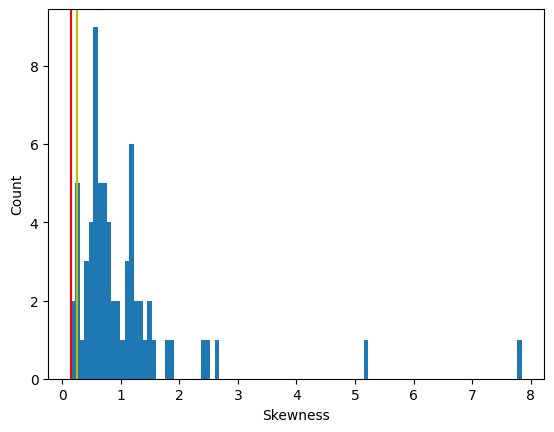

In [19]:
fig, ax = plt.subplots()
ax.hist(bod.dff_traces.skewness.values.flatten(), bins=100);
ax.axvline(bod.dff_traces.loc[5].skewness, color='r')
ax.axvline(bod.dff_traces.loc[60].skewness, color='y')
ax.set_xlabel('Skewness')
ax.set_ylabel('Count')

Text(0, 0.5, 'Count')

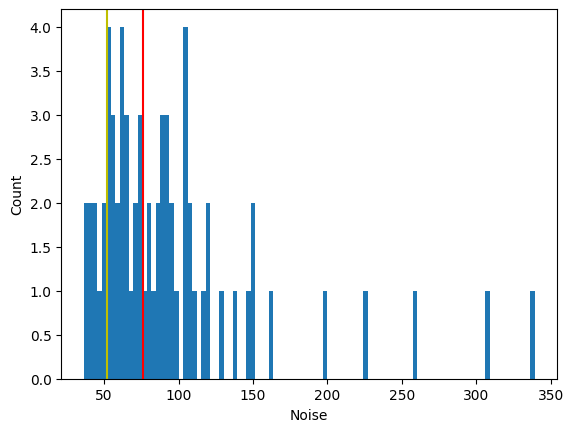

In [20]:
fig, ax = plt.subplots()
ax.hist(bod.dff_traces.noise.values.flatten(), bins=100);
ax.axvline(bod.dff_traces.loc[5].noise, color='r')
ax.axvline(bod.dff_traces.loc[60].noise, color='y')
ax.set_xlabel('Noise')
ax.set_ylabel('Count')

In [22]:
dff_table = bod.dff_traces.copy()
dff_table['signal'] = dff_table.dff.apply(lambda x: np.percentile(x, 99))
dff_table['snr'] = dff_table.signal / dff_table.noise

Text(0, 0.5, 'Count')

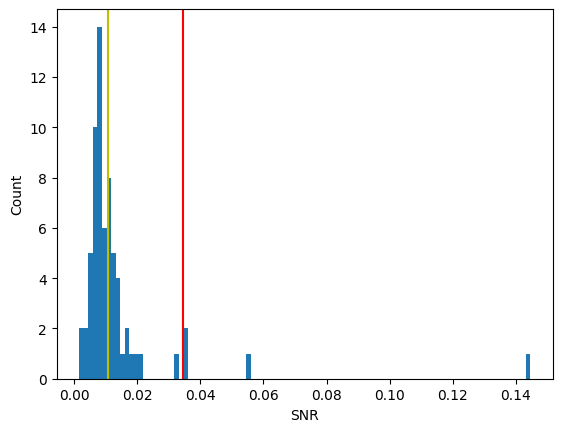

In [23]:
fig, ax = plt.subplots()
ax.hist(dff_table.snr.values.flatten(), bins=100);
ax.axvline(dff_table.loc[5].snr, color='r')
ax.axvline(dff_table.loc[60].snr, color='y')
ax.set_xlabel('SNR')
ax.set_ylabel('Count')